## **IPF for fertility model, July 2025**
### To compute IPF solution for births and population for age, ethnicity and parity; data to come from ONS and *NewEthPop*

- Existing fertility model - implemented in Minos - takes ONS data *NewEthPop* data, expands to higher parity values using geometric series, then matches mean fertility rate per cell (i.e. each $(a, e, p)$ combination) to that in *NewEthPop*
- Not ideal because some data not very good or missing entirely, most importantly population by ethnicity, which means final fertility rate may not capture ethnicity dependence correctly
- Aim is to replace with better model that accounts for ethnicity, i.e. to compute fertility rate table as function of age, ethnicity and parity, i.e. $f(a, e, p)$
- For such a 3D table constructed using IPF, ideal constraints are three 2D cross-tabulations for each combination of variables; data sources in table below
- Methodology does **not** require any manual setting to reference values and instead preserves relationships between $(a, e, p)$ through the constraints and seed data given to IPF
- Important to note that constraints data are not available for every year that Minos will run for (i.e. 2020-2035 or so)
- However, used nearest-year methodology to get constraints for nearest available year; result is that some or most *relationships between variables* are represented for all years thus produced

 Dataset ID | Variables ($xyz$)$^{1}$ | Data source | File name(s)$^{2}$ |
| --- | --- | --- | --- |
| *Population ($P$)* |
| 1 | $xy \;(ae)$ | *NewEthPop* | ```Population2020_LEEDS2.csv```$^{3}$ |
| 2 | $yz \;(ep)$ | *NewEthPop* and ONS$^{4}$ | ```Population2020_LEEDS2.csv```$^{3}$ (for $e$) and <br> ```finalfertilityratesbyparity1934to2022.xlsx``` (for $p$) |
| 3 | $xz \;(ap)$ | ONS | ```finalfertilityratesbyparity1934to2022.xlsx``` |
| *Births ($b$)* |
| 4 | $xy \;(ae)$ | *NewEthPop*$^{5}$ | ```Fertility2020_LEEDS1_2.csv```$^{6}$ (for $f$) and <br> ```Population2020_LEEDS2.csv```$^{3}$ (for $P$) |
| 5 | $yz \;(ep)$ | ONS | ```20182022livebirthssexparity.xlsx```$^{7}$ |
| 6 | $xz \;(ap)$ | ONS | ```finalfertilityratesbyparity1934to2022.xlsx``` |

$^{1}$ Variables $x$ = age ($a$), $y$ = ethnicity ($e$) and $z$ = parity ($p$); also $f$ = fertility rate

$^{2}$ If multiple years available, data for 2020 given as example

$^{3}$ Via ```OutputData/Population``` folder

$^{4}$ Dataset not available directly; must compute 2D IPF solution, $P(e, p)$, using 1D constraints, $P(e)$ and $P(p)$

$^{5}$ Births by age and ethnicity not given directly, so necessary to calculate $b(a, e) = f(a, e) \cdot P(a, e)$

$^{6}$ Via ```InputData/Fertility``` folder

$^{7}$ Data given as total for 2018-2022, i.e. five years; must divide by five

In [1]:
import os
from os.path import dirname as up
import sys

HOME = os.path.expanduser("~")
SYNTHPOP_PATH = os.path.join(HOME, "miniconda3/envs/synthpop_sandbox/lib/python3.11")  # Nasty workaround during development - Synthpop Sandbox was saved to Python 3.11 folder first (my fault - tried with 3.11 before finding conflict with Minos, which needs 3.9)
sys.path.append(SYNTHPOP_PATH)

import synthpop_sandbox
import ipfn
import pyipf

# All other setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from minos.utils import extend_series
from minos.RateTables import FertilityRateTable
from minos import fertility_utils as futils

PERSISTENT_DATA = os.path.join(HOME, 'code', 'Minos', 'persistent_data',)
SYNTHPOP_PATH = os.path.join(HOME, 'code', 'Minos', 'data', 'scaled_gb_US')
DESKTOP = os.path.join("/mnt/c/Users", 'prehr', 'Desktop')
NEP_DATA_PATH = os.path.join(DESKTOP, 'Leeds2Projections', '2DataArchive')


def get_nearest(value, ref_values):
    j = {k: abs(k - value) for k in ref_values}
    nearest = min(j, key=j.get)
    return nearest

# HR 02/08/25 To get nearest year in NewEthpop data
def get_nearest_newethpop(year):
    pop_path = os.path.join(NEP_DATA_PATH, 'OutputData', 'Population')
    pop_years = [int(f.lstrip('Population').split('_')[0]) for f in os.listdir(os.path.join(pop_path)) if f.endswith('csv')]
    nearest_newethpop = get_nearest(year, pop_years)
    return nearest_newethpop

# HR 02/08/25 To get nearest year in ONS pop-births data
def get_nearest_ons(year):
    fert_ons = FertilityRateTable.parse_parity_ons()
    fert_years = fert_ons['year'].unique()
    nearest_ons = get_nearest(year, fert_years)
    return nearest_ons

# HR 30/07/25 For normalising constraints to reference totals
# Must use ONS fertility data, as common to population and births constraints calculations
def normalise_to_reference(to_be_normalised, reference_dataset):
    _sum = int(reference_dataset.sum().sum())
    normalised = []
    for dataset in to_be_normalised:
        dataset = dataset * _sum / dataset.sum().sum()
        normalised.append(dataset)
    return normalised

def get_synthpop_data(path=SYNTHPOP_PATH, pc=1):
    sp_file = '2019_US_cohort.csv'
    sp_full = os.path.join(path, str(pc) + 'pc', sp_file)
    sp = pd.read_csv(sp_full)
    return sp


# Any parameters for constraints data and IPF input
year = 2020
age_range = (15, 44)
fill_value_threshold = 1e-3
fill_value = 1e-8
# normaliser = 'nep'
normaliser = 'ons'
scale_factor = 50.7860 / 53.2242  # Observed (synthpop) vs. reference (ONS or NEP)

# Get nearest years in data
fert_ons = FertilityRateTable.parse_parity_ons()
year_nearest_ons = get_nearest_ons(year)
year_nearest_newethpop = get_nearest_newethpop(year)

print('Nearest years:')
print('ONS:', year_nearest_ons)
print('NEP:', year_nearest_newethpop)

Nearest years:
ONS: 2020
NEP: 2020


## Dataset 1

In [2]:
eth_map = futils.get_ethnicity_map()
filename_1 = 'Population' + str(year_nearest_newethpop) + '_LEEDS2.csv'
ageeth_p = pd.read_csv(os.path.join(NEP_DATA_PATH, 'OutputData', 'Population', filename_1))

headline_cols = ['LAD.code', 'ETH.group']  # Headers to retain; common to NEP pop and births data

# Tidy pop data
dfp = ageeth_p.T
dfp = dfp.loc[~dfp.index.str.startswith('M')]
dfp = dfp.loc[~dfp.index.astype(str).isin(headline_cols)]
dfp = dfp.loc[dfp.index.str.startswith('F')]
dfp.index = dfp.index.str.rstrip('p').str.lstrip('F').astype(int)
tidy_p = pd.concat([ageeth_p[headline_cols], dfp.loc[age_range[0]:age_range[1]].T], axis=1).set_index(headline_cols)

ethnic_group = tidy_p.reset_index()['ETH.group'].map(eth_map).tolist()  # "To list" avoids index mismatch
tidy_p['ethnicity'] = ethnic_group
xy_p = tidy_p.groupby('ethnicity').sum().T
xy_p.columns = [el.lower() for el in xy_p.columns]
xy_p

,asian,black,mixed,other,white
15,36660.864105,18276.991785,18299.707406,5162.230793,283823.652448
16,35815.049836,17473.671568,17142.966348,5010.869420,282964.960768
17,35966.092840,16769.683915,15843.619177,4989.440626,277323.343552
18,36263.189605,16202.362796,15193.058482,4893.947661,277029.909088
19,39763.384182,16832.278740,15113.923785,5012.937644,289383.163556
20,42861.332820,17066.334552,15363.563105,5365.598548,299656.513868
21,46130.854382,17211.511938,15381.674159,5603.466262,312775.619932
22,49752.820304,17680.412471,15240.467842,5833.838453,322011.153590
23,53501.679516,17718.972355,15375.199683,6331.388100,336175.752652
24,55708.387491,17547.372601,14534.698690,6388.740654,339862.837155


## Dataset 2

In [3]:
### 1. Get population by ethnicity
margin_e = tidy_p.groupby('ethnicity').sum().sum(axis=1).to_list()

### 2. Get population by parity
# HR 29/07/25 Get ONS data for population by age and parity 
fert_ym = fert_ons.loc[(fert_ons['year'] == year_nearest_ons), ['age', 'p1', 'p2', 'p3', 'p4', 'p5']].set_index('age')

margin_p = fert_ym.sum()
margin_p = extend_series(margin_p.to_list(), 6)
corrector = sum(margin_e) / sum(margin_p)
margin_p = [el*corrector for el in margin_p]

### 3. Get population by ethnicity and parity using IPF
dims = (len(margin_e), len(margin_p))
m = np.ones(dims)
aggregates = [margin_e, margin_p]
dimensions = [[0], [1]]

model = ipfn.ipfn.ipfn(m.copy(), aggregates, dimensions, verbose=2)  # Must copy m as it is mutated
result = model.iteration()

# Final format
yz_p = pd.DataFrame(result[0])
yz_p.index = [el.lower() for el in xy_p.columns]
yz_p

ipfn converged: convergence_rate below threshold


,0,1,2,3,4,5,6,7,8,9
asian,8.315698e+05,2.054442e+05,3.009913e+05,122097.429055,41998.213655,14446.249719,4969.119227,1709.242632,587.933241,202.233135
black,2.833190e+05,6.999562e+04,1.025489e+05,41599.059968,14308.951646,4921.892402,1692.997881,582.345487,200.311099,68.901601
mixed,2.073779e+05,5.123392e+04,7.506158e+04,30448.803107,10473.564827,3602.623059,1239.204905,426.252975,146.619496,50.433142
other,1.047429e+05,2.587735e+04,3.791228e+04,15379.152487,5290.012550,1819.621257,625.900503,215.292847,74.054917,25.472889
white,5.540656e+06,1.368852e+06,2.005471e+06,813521.455465,279829.380227,96253.739237,33108.683261,11388.491668,3917.333149,1347.456665


## Dataset 3

In [4]:
val = fert_ym.loc[age_range[0]:age_range[1]]
valx = val.apply(lambda x: extend_series(x.to_list(), 6), axis=1)
valx = pd.DataFrame(valx.to_list())
valx.index = val.index
xz_p = valx
xz_p

,0,1,2,3,4,5,6,7,8,9
age,,,,,,,,,,
15,329948,78,1,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
16,326516,347,10,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
17,317902,1243,55,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
18,316669,3607,253,10.0,0.909091,0.082645,0.007513,0.000683,0.000062,0.000006
19,323923,8070,923,54.0,4.576273,0.387820,0.032866,0.002785,0.000236,0.000020
20,323910,14311,2551,233.0,19.263785,1.592676,0.131678,0.010887,0.000900,0.000074
21,326515,21156,5314,643.0,76.631700,9.132842,1.088437,0.129718,0.015460,0.001842
22,323950,27016,9563,1443.0,171.786145,20.450783,2.434623,0.289837,0.034504,0.004108
23,326513,33737,15722,2656.0,411.545380,63.768674,9.880912,1.531041,0.237234,0.036759


## Dataset 4

In [5]:
filename_4 = 'Fertility' + str(year_nearest_newethpop) + '_LEEDS1_2.csv'
ageeth_f = pd.read_csv(os.path.join(NEP_DATA_PATH, 'InputData', 'Fertility', filename_4))

# Tidy fertility data
dff = ageeth_f.T
dff = dff.loc[~dff.index.str.startswith('M')]
dff = dff.loc[~dff.index.astype(str).isin(headline_cols)]
dff = dff.loc[dff.index.str.startswith('F')]
dff.index = dff.index.str.rstrip('p').str.lstrip('F').str.split('.').str[-1].astype(int) - 1
tidy_f = pd.concat([ageeth_f[headline_cols], dff.loc[age_range[0]:age_range[1]].T], axis=1).set_index(headline_cols)

tidy_b = tidy_p * tidy_f
ethnic_group = tidy_b.reset_index()['ETH.group'].map(eth_map).tolist()  # "To list" avoids index mismatch
tidy_b['ethnicity'] = ethnic_group

# 1. Get births by age-ethnicity
xy_b = tidy_b.groupby('ethnicity').sum().T
xy_b.columns = [el.lower() for el in xy_b.columns]
xy_b

,asian,black,mixed,other,white
15,1126.038330,419.826356,62.465825,19.475476,2891.172232
16,1536.664674,577.955907,111.590570,36.260498,4717.990753
17,2032.039948,727.727772,179.744147,62.318590,6981.810244
18,2625.341843,901.022441,277.432474,97.942432,9956.301536
19,3222.041950,1144.825506,393.870948,144.148305,13502.348639
20,3886.407090,1336.319884,541.649811,208.420594,17323.781461
21,4623.225158,1524.079810,700.294042,281.189036,21729.407601
22,5373.742186,1727.619826,863.600692,362.644239,26214.564185
23,6205.536493,1870.404744,1036.277647,468.892703,30698.546380
24,6753.259006,1934.874270,1102.050413,535.136391,33390.497889


## Dataset 5

In [6]:
# HR 22/07/25 Get birth data (births yz)
ETH_FILE = "20182022livebirthssexparity.xlsx"
ETH_FULL = os.path.join(PERSISTENT_DATA, ETH_FILE)

eth_raw = pd.read_excel(ETH_FULL,
                        sheet_name='2',
                        header=5,
                       )

ethnicity = ['asian', 'black', 'asian', 'black', 'black', 'asian', 'mixed', 'not stated', 'other', 'asian', 'white', 'white']
valid_eth = ['asian', 'black', 'mixed', 'other', 'white']
eth_raw.insert(0, 'ethnicity', ethnicity)
eth_raw.drop(columns=eth_raw.columns[1], inplace=True)
eth_raw = eth_raw.loc[eth_raw.ethnicity != 'not stated']

eth_t = eth_raw.groupby('ethnicity').sum().T
eth_tp = eth_t.loc[eth_t.index.str.split(' ').str[0].isin(('First', 'Second', 'Third'))].copy()
eth_tp['parity'] = eth_tp.index.str[0].map({'F': 0, 'S': 1, 'T': 2})

eth_tpg = eth_tp.groupby('parity').sum().T
eth_ext = eth_tpg.apply(lambda x: extend_series(x.to_list(), 8), axis=1)
eth_done = pd.DataFrame(eth_ext.to_list())
eth_done.index = eth_ext.index
yz_b = eth_done / 5  # Accounts for data being for five-year period, 2018-2022
yz_b

,0,1,2,3,4,5,6,7,8,9
ethnicity,,,,,,,,,,
asian,29007.4,25567.4,11365.162156,5052.015881,2245.710542,998.258112,443.743412,197.251807,87.681922,38.976167
black,10328.2,9320.6,5095.239709,2785.385886,1522.671155,832.390032,455.037953,248.753025,135.984410,74.337829
mixed,19470.0,13629.2,5237.907512,2013.007008,773.629012,297.317320,114.263539,43.913205,16.876508,6.485897
other,5942.4,4700.0,2217.618848,1046.347522,493.702125,232.945348,109.911488,51.859955,24.469279,11.545433
white,194368.6,155363.4,56977.733978,20895.926385,7663.339852,2810.441452,1030.696969,377.996218,138.625751,50.839394


## Dataset 6

In [7]:
# HR 22/07/25 Get ONS data for births by age and parity 
fert_ym = fert_ons.loc[(fert_ons['year'] == year_nearest_ons), ['age', 'b1', 'b2', 'b3', 'b4', 'b5']].set_index('age')

val = fert_ym.loc[age_range[0]:age_range[1]]
valx = val.apply(lambda x: extend_series(x.to_list(), 6), axis=1)
valx = pd.DataFrame(valx.to_list())
valx.index = val.index
xz_b = valx
xz_b

,0,1,2,3,4,5,6,7,8,9
age,,,,,,,,,,
15,285,12,0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
16,860,30,2,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
17,2226,178,4,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
18,3886,558,18,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
19,6380,1293,132,4.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
20,8037,2372,327,41.0,4.456528,0.484406,0.052653,0.005723,0.000622,0.000068
21,8860,3548,698,115.0,17.757556,2.742007,0.423403,0.065379,0.010095,0.001559
22,9380,4784,1086,206.0,43.412963,9.148958,1.928075,0.406327,0.085630,0.018046
23,10583,5949,1697,394.0,75.243199,14.369388,2.744159,0.524059,0.100081,0.019113


## IPF solutions (births and population must be done separately)

In [8]:
# HR 29/07/25 Example from IPFN Github, for testing
# xijp = np.array([[9, 17, 19, 7], [11, 13, 16, 8]])  # xy 2x3
# xpjk = np.array([[7, 9, 4], [8, 12, 10], [15, 12, 8], [5, 7, 3]])  # yz, 4x3
# xipk = np.array([[22, 20, 10], [13, 20, 15]])  # xz, 2x3

### Population and births constraints datasets ###
# 1. Fill structural (i.e. real) zeroes with small value to prevent IPF having a nervous breakdown
constraints = [xy_p, yz_p, xz_p, xy_b, yz_b, xz_b]
for c in constraints:
    c[c < fill_value_threshold] = fill_value

# 2. Normalise all constraints to reference dataset; use ONS births/pop dataset here as single source
# Normalise to NEP or ONS data
if normaliser == 'nep':
    xy_p_corr, yz_p_corr, xz_p_corr = normalise_to_reference([xy_p, yz_p, xz_p], xy_p)
    xy_b_corr, yz_b_corr, xz_b_corr = normalise_to_reference([xy_b, yz_b, xz_b], xy_b)
elif normaliser == 'ons':
    xy_p_corr, yz_p_corr, xz_p_corr = normalise_to_reference([xy_p, yz_p, xz_p], xz_p)
    xy_b_corr, yz_b_corr, xz_b_corr = normalise_to_reference([xy_b, yz_b, xz_b], xz_b)

# Define constraints sets for population and births data
pop_constraints = [xy_p_corr, yz_p_corr, xz_p_corr]
births_constraints = [xy_b_corr, yz_b_corr, xz_b_corr]

# xijp, xpjk, xipk = pop_constraints
xijp, xpjk, xipk = births_constraints

# Create uniform seed
m = np.ones((xijp.shape[0], xpjk.shape[0], xipk.shape[1]))

In [9]:
# TEST 1: Using IPFN, repo here: https://github.com/Dirguis/ipfn
aggregates_ipfn = [xijp, xpjk, xipk]
dimensions_ipfn = [[0, 1], [1, 2], [0, 2]]

# HR 31/07/25 Rotate order
def rotate_order(list_in, number):
    list_out = list_in.copy()
    for i in range(number):
        list_out.append(list_out.pop(0))
    return list_out

# shift = 1
# # aggregates_ipfn, dimensions_ipfn = [rotate_order(d, shift) for d in (aggregates_ipfn, dimensions_ipfn)]
# aggregates_ipfn = rotate_order(aggregates_ipfn, shift)
# m_new_dims = rotate_order(list(m.shape), -shift)
# m = m.reshape(m_new_dims)


# model_ipfn = ipfn.ipfn.ipfn(m.copy(), aggregates_ipfn, dimensions_ipfn, verbose=2)  # Must copy m as it is mutated
# result_ipfn = model_ipfn.iteration()

# print('Final convergence value: {}'.format(result_ipfn[-1].conv.iloc[-1]))
# print('Convergence sequence:\n', result_ipfn[-1])

# print('\nTarget sum (xy constraint):', aggregates_ipfn[0].sum().sum())
# print('IPFN gives:', result_ipfn[0].sum(), '\n')

# print('xy constraint vs. computed:')
# print(aggregates_ipfn[0], '\n\n', result_ipfn[0].sum(axis=2), '\n')

# print('Value at [0, 0] (xy constraint): {}'.format(aggregates_ipfn[0].to_numpy()[0,0]))
# print('Value at [0, 0] (IPFN result):', result_ipfn[0][0, 0, :].sum())

# # print('\n', result_ipfn[0])  # Solution


# # TEST 2: Using PyIPF
# # aggregates_pyipf = [xpjk, xipk, xijp]  # Note different order of constraints to IPFN
# aggregates_pyipf = rotate_order(aggregates_ipfn, 1)  # This accounts for different order used by PyIPF relative to IPFN
# result_pyipf = pyipf.ipf(m.copy(), aggregates_pyipf, max_itr=100, pbar=True, tol_convg=1e-6)

# print('\nTarget sum (xy constraint):', aggregates_pyipf[0].sum().sum())
# print('PyIPF gives:', result_pyipf.sum(), '\n')

# print('\nTarget sum (yz constraint):', aggregates_pyipf[1].sum().sum())
# print('PyIPF gives:', result_pyipf.sum(), '\n')

# print('\nTarget sum (xz constraint):', aggregates_pyipf[2].sum().sum())
# print('PyIPF gives:', result_pyipf.sum(), '\n')

# print('xy constraint vs. computed:')
# print(aggregates_pyipf[0], '\n\n', result_pyipf.sum(axis=0), '\n')

# print('yz constraint vs. computed:')
# print(aggregates_pyipf[1], '\n\n', result_pyipf.sum(axis=1), '\n')

# print('xz constraint vs. computed:')
# print(aggregates_pyipf[2], '\n\n', result_pyipf.sum(axis=2), '\n')

# # print('\n', result)  # Solution

In [10]:
### USE PYIPF TO GET SOLUTIONS FOR POPULATION AND BIRTHS ###
pyipf_params = {'tol_convg': 1e-6,
                'convg': 'relative',
                'pbar': True,
               }

# HR 01/08/25 Example for 3D case with 2D constraints from PyIPF documentation below
# Buried in Jupyter notebook here: https://github.com/MutaharChalmers/pyipf/blob/main/docs/README.ipynb
# PyIPF repo here: https://github.com/MutaharChalmers/pyipf
# dims = (3, 4, 5)

# Target matrix
# M = np.random.lognormal(size=dims)

# m0 = M.sum(axis=0)  # yz
# m1 = M.sum(axis=1)  # xz
# m2 = M.sum(axis=2)  # xy

# Get dimensions of seed table
dims = m.shape


### BIRTHS ###
m0 = yz_b_corr.to_numpy()  # yz
m1 = xz_b_corr.to_numpy()  # xz
m2 = xy_b_corr.to_numpy()  # xy

marginals_births = [m0, m1, m2]

# Create seed table
# M0 = np.random.lognormal(size=dims)
# M0 = np.ones(dims)
M0 = np.stack([m1]*5, axis=1)  # To retain zeroes
M1 = pyipf.ipf(M0, marginals_births, **pyipf_params)

# print(m0)
# print(M1.sum(axis=0), '\n')
# print(m1)
# print(M1.sum(axis=1), '\n')
# print(m2)
# print(M1.sum(axis=2), '\n')


### POPULATION ###
m3 = yz_p_corr.to_numpy()  # yz
m4 = xz_p_corr.to_numpy()  # xz
m5 = xy_p_corr.to_numpy()  # xy

marginals_pop = [m3, m4, m5]

# Create seed table
# M2 = np.random.lognormal(size=dims)
# M2 = np.ones(dims)
M2 = np.stack([m4]*5, axis=1)  # To retain zeroes
M3 = pyipf.ipf(M2, marginals_pop, **pyipf_params)

# print(m3)
# print(M3.sum(axis=0), '\n')
# print(m4)
# print(M3.sum(axis=1), '\n')
# print(m5)
# print(M3.sum(axis=2), '\n')

  0%|          | 0/1000 [00:00<?, ?it/s]

[[2.94662264e+04 2.59718140e+04 1.15449313e+04 5.13192646e+03
  2.28123221e+03 1.01404812e+03 4.50762352e+02 2.00371849e+02
  8.90688361e+01 3.95926753e+01]
 [1.04915670e+04 9.46802918e+03 5.17583398e+03 2.82944390e+03
  1.54675610e+03 8.45556414e+02 4.62235545e+02 2.52687692e+02
  1.38135352e+02 7.55136720e+01]
 [1.97779680e+04 1.38447807e+04 5.32075844e+03 2.04484787e+03
  7.85865937e+02 3.02020155e+02 1.16070909e+02 4.46078045e+01
  1.71434533e+01 6.58848817e+00]
 [6.03639429e+03 4.77434255e+03 2.25269617e+03 1.06289819e+03
  5.01511290e+02 2.36629976e+02 1.11650020e+02 5.26802531e+01
  2.48563239e+01 1.17280537e+01]
 [1.97443038e+05 1.57820870e+05 5.78789829e+04 2.12264490e+04
  7.78455521e+03 2.85489579e+03 1.04700008e+03 3.83975198e+02
  1.40818472e+02 5.16435496e+01]]
[[4.09286721e+04 2.99416345e+04 1.27905072e+04 5.31632342e+03
  2.26981467e+03 1.00664484e+03 4.56163171e+02 2.08751557e+02
  9.56826226e+01 4.36951531e+01]
 [1.06195878e+04 7.95420867e+03 4.17869738e+03 2.13597531

  0%|          | 0/1000 [00:00<?, ?it/s]

[[7.48101909e+05 1.84822976e+05 2.70779667e+05 1.09842042e+05
  3.77826919e+04 1.29962242e+04 4.47034967e+03 1.53767939e+03
  5.28920127e+02 1.81934220e+02]
 [2.54881175e+05 6.29698931e+04 9.22556659e+04 3.74236028e+04
  1.28727073e+04 4.42786319e+03 1.52306519e+03 5.23893237e+02
  1.80205106e+02 6.19856829e+01]
 [1.86562550e+05 4.60913751e+04 6.75273578e+04 2.73925400e+04
  9.42229296e+03 3.24101397e+03 1.11482116e+03 3.83468329e+02
  1.31902735e+02 4.53709737e+01]
 [9.42294480e+04 2.32799392e+04 3.41068754e+04 1.38354880e+04
  4.75903370e+03 1.63697889e+03 5.63076470e+02 1.93683078e+02
  6.66217410e+01 2.29160772e+01]
 [4.98451899e+06 1.23145473e+06 1.80417451e+06 7.31865187e+05
  2.51741832e+05 8.65923823e+04 2.97854378e+04 1.02453851e+04
  3.52413540e+03 1.21220727e+03]]
[[7.49693713e+05 1.88297592e+05 2.68969925e+05 1.08395722e+05
  3.65608355e+04 1.25292404e+04 4.34597527e+03 1.52234307e+03
  5.37721751e+02 1.91326397e+02]
 [2.55423509e+05 6.41537081e+04 9.16390796e+04 3.69308361

In [11]:
# # Compare competing constraint sets
# print(xy_b_corr.sum(axis=0))
# print(yz_b_corr.sum(axis=1))

# print(xz_b_corr.sum(axis=0))
# print(yz_b_corr.sum(axis=0))

# print(xy_b_corr.sum(axis=1))
# print(xz_b_corr.sum(axis=1))

## Analysis section

In [12]:
# Compute fertility rate and compare 2D value (i.e. (a, e)) to 3D value (i.e. (a, e, p))
# This consists of summing over parity dimension
births_result = M1
pop_result = M3

try:
    fert_result = (M1 / scale_factor) / M3
except:
    fert_result = M1 / M3
f = fert_result

# 3D value
gfr = 1000 * M1.sum().sum() / M3.sum().sum()

# 2D value
parity_dimension = 2
b_ae = births_result.sum(axis=parity_dimension)
p_ae = pop_result.sum(axis=parity_dimension)
f_ae = 1000 * b_ae / p_ae
f_2d = 1000 * b_ae.sum().sum() / p_ae.sum().sum()

# # Tidy up for display
# f_ae = pd.DataFrame(f_ae, columns=['asian', 'black', 'mixed', 'other', 'white'])
# f_ae.index = f_ae.index + 15
# print(f_ae)

# Compare results
print('### Comparing 3D and 2D GFR values (births per 1,000 women aged 15-44) ###')
print("GFR(a, e, p) = {0:.6g}".format(gfr))
print("GFR(a, e)    = {0:.6g}".format(f_2d))

### Comparing 3D and 2D GFR values (births per 1,000 women aged 15-44) ###
GFR(a, e, p) = 53.2242
GFR(a, e)    = 53.2242


In [13]:
# See whether truncating/correcting fertility results affect GFR
fc = f.copy()

# Get conditions for correcting zero and very large fertility values, then correct
zerof_mask = (fc < 1e-4)
trunc_mask = (fc > 1)
fc[zerof_mask] = 0
fc[trunc_mask] = 1

# Get corresponding population size, for validation
zerof_pop = 100 * M3[fc == 0].sum() / M3.sum()
trunc_pop = 100 * M3[fc == 1].sum() / M3.sum()

print('### Calculating zero and unity cells in fertility rate table ###')
print('Zero cells in result: {}'.format(len(fc[fc == 0])))
print('Unity cells in result: {}'.format(len(fc[fc == 1])))

print('Proportion of population with zero fertility rate (i.e. f = 0): {0:.4g}%'.format(zerof_pop))
print('Proportion of population with truncated fertility rate (i.e. f > 1 before correction): {0:.4g}%'.format(trunc_pop))

### Calculating zero and unity cells in fertility rate table ###
Zero cells in result: 40
Unity cells in result: 214
Proportion of population with zero fertility rate (i.e. f = 0): 6.018e-05%
Proportion of population with truncated fertility rate (i.e. f > 1 before correction): 0.003156%


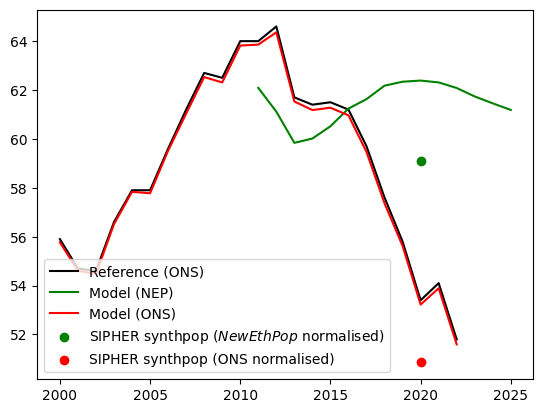

In [14]:
# Plot up GFR (births/female population, 15-44) against reference data
model_data_nep = pd.Series({2011: 62.0863,
                            2012: 61.1154,
                            2013: 59.8382,
                            2014: 60.0165,
                            2015: 60.5185,
                            2016: 61.241,
                            2017: 61.629,
                            2018: 62.1785,
                            2019: 62.3398,
                            2020: 62.3867,
                            2021: 62.3117,
                            2022: 62.0833,
                            2023: 61.7361,
                            2024: 61.4552,
                            2025: 61.1848,
                           })

model_data_ons = pd.Series({2000: 55.7705,
                            2001: 54.6093,
                            2002: 54.4762,
                            2003: 56.5162,
                            2004: 57.8353,
                            2005: 57.776,
                            2006: 59.5188,
                            2007: 61.0349,
                            2008: 62.5305,
                            2009: 62.3103,
                            2010: 63.8195,
                            2011: 63.8589,
                            2012: 64.36,
                            2013: 61.5309,
                            2014: 61.1811,
                            2015: 61.2765,
                            2016: 60.9644,
                            2017: 59.4641,
                            2018: 57.364,
                            2019: 55.6195,
                            2020: 53.2242,
                            2021: 53.891,
                            2022: 51.595,
                           })

synthpop_result_nep = {2020: 59.1167,
                      }
synthpop_result_ons = {2020: 50.8544,
                      }

ref_data = futils.get_fertility_reference_data()
ref_data = ref_data.loc[ref_data.index >= 2000]['gfr_ref']

# ref_data_hfd = futils.get_fertility_reference_data(sources={'gfr': 'hfd', 'mort': 'ons', 'tfr': 'ons', 'cbr': 'ons', 'sma': 'ons'})
# ref_data_hfd = ref_data_hfd['gfr_ref']

fig = plt.figure()
ax1 = fig.add_subplot(111)

ax1.plot(ref_data, label='Reference (ONS)', c='black')
# ax1.plot(ref_data, label='Reference (HFD)', c='gray')
ax1.plot(model_data_nep, label='Model (NEP)', c='green')
ax1.plot(model_data_ons, label='Model (ONS)', c='red')
ax1.scatter(*zip(*synthpop_result_nep.items()), label='SIPHER synthpop ($\it{NewEthPop}$ normalised)', c='green')
ax1.scatter(*zip(*synthpop_result_ons.items()), label='SIPHER synthpop (ONS normalised)', c='red')
plt.legend(loc=3)
plt.show()

## Apply fertility rate table to microsim input population

In [15]:
# Get 1% synthpop and tidy up
sp20_raw = get_synthpop_data(pc=1)
sp20 = sp20_raw.loc[(sp20_raw['sex'] == 'Female') & (sp20_raw['age'].between(*age_range))]
sp20['eth_group'] = sp20['ethnicity'].map(eth_map).str.lower()
sp20['age'] = sp20['age'].astype(int)
sp20.eth_group.value_counts(dropna=False)

# Get crosstab for tabular calculation
# sp20ct = pd.crosstab([sp20['age'], sp20['eth_group']], sp20['nkids_ind'])

# Convert to dict with tuples as keys
# sp20gb = sp20.groupby(['age', 'eth_group', 'nkids_ind']).size().unstack(fill_value=0).stack()  # Without unstack/stack, empty cases are excluded, e.g. 16/Asian/1

# Convert fertility table into DF then dict of tuples
age_cats = list(xy_p.index)
eth_cats = list(xy_p.columns)
par_cats = list(yz_p.columns)

fertd = {}
for i, sub in enumerate(fc):
    df = pd.DataFrame(fc[i])
    df.columns = par_cats
    df.index = eth_cats
    dsub = {(age_cats[i], *k): v for k, v in df.stack().to_dict().items()}
    fertd = fertd | dsub

# Add tuple column, map fertility rates and get newborns
sp20['fertcat'] = sp20[['age', 'eth_group', 'nkids_ind']].apply(tuple, axis=1)
sp20['rnd'] = np.random.rand(len(sp20))
sp20['fertval'] = sp20['fertcat'].map(fertd).fillna(0)
sp20['newborn'] = sp20['fertval'] > sp20['rnd']

nnewborn = len(sp20.loc[sp20['newborn']])
ntotal = len(sp20)

print("GFR = {} per 1,000 ({}/{})".format(1000*nnewborn/ntotal, nnewborn, ntotal))

GFR = 53.28701411768723 per 1,000 (6243/117158)
